In [1]:
import GridFlowSmooth as flow
import numpy as np
import pypower
# import andes
import os
import itertools
import time
import random
# import pandapower
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import pulp
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpBinary, value

# test the dc opf tep

In [2]:
sus = {(1,2):200, (4,6):300, (5,7):100, (7,2):200, (1,3):200, (2,3):100, (2,4):200, (3,5):200, (1,6):200}
line_capacity = {key:sus[key]*3 for key in sus.keys()}
poss_dc_lines_cost = {(3,4):1000}
poss_dc_lines = list(poss_dc_lines_cost.keys())
poss_ac_lines_cost = {(1, 3):1e4,(2, 3):1e4, (2, 4):1e4, (3,5):1e4}
poss_ac_lines = list(poss_ac_lines_cost.keys())
dc_lines = [(3,7)]
line_capacity.update({key:1000 for key in dc_lines + poss_dc_lines})
_=flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:100,5:100}, max_new_ac = 1, max_new_dc = 0, max_new = 1,
                 susceptances = sus, line_capacity = line_capacity, cut = False,
                 obj = 'cost', dc_lines = dc_lines,
                 poss_dc_lines_cost = poss_dc_lines_cost,
                 demands = {1: 50, 2: 60, 3: 40, 4: 30, 5:50, 6:20, 7:60}, 
                 ac_lines = [(1, 2), (4,6), (5,7), (7,2)], save = False,
                 poss_ac_lines_cost = {(1, 6):1e6,(2, 3):1e4, (2, 4):1e5, (3,5):1e4},
                 printout = True, label="",
                 generation_cost = {1: 100, 2: 10, 5: 1})

Status: Optimal
Objective Value: 112100.0

Generation at Each Bus:
Bus 1: 110.0 MW
Bus 2: 100.0 MW
Bus 5: 100.0 MW

AC Line Flows:
Line (1, 2): 60.0 MW
Line (4, 6): 20.0 MW
Line (5, 7): 50.0 MW
Line (7, 2): -50.0 MW
New AC Line (1, 6): 0.0 MW
New AC Line (2, 3): 0.0 MW
New AC Line (2, 4): 50.0 MW
New AC Line (3, 5): 0.0 MW

DC Line Flows:
Line (3, 7): -40.0 MW

New AC Line Decisions:
Line (1, 6): Not Added
Line (2, 3): Not Added
Line (2, 4): Added
Line (3, 5): Not Added

New DC Line Decisions:
Line (3, 4): Not Added

Voltage phases:
Bus 1: -2.5249259869233334 rads
Bus 2: -2.824925986923333 rads
Bus 3: -3.14159265359 rads
Bus 4: -3.074925986923333 rads
Bus 5: -2.574925986923333 rads
Bus 6: -3.14159265359 rads
Bus 7: -3.074925986923333 rads


# When's AC insufficient?

## Loop
Generator 1 is too expensive, and cheaper generator 3 can fulfill all of node 2's needs. 
Ideally, power would go on line 3-2, which has sufficient capacity. But the limited capacity in line 1-3 causes problems.

Edit `max_new` to 0 or 1 to see the difference

In [5]:
from collections import defaultdict

dc_boss_map = defaultdict(list)
for load1 in [0,40,160,400]:
    for load3 in [0,40,160,400]:
        for cap31 in [4,8,16,32,64,100,128,256]:
            dc_boss_map['demand1'] += [load1]
            dc_boss_map['demand3'] += [load3]
            dc_boss_map['cap31'] += [cap31]
            ac_lines = [(1, 2), (3,1), (2,3)]
            poss_ac_lines_cost = { (2, 3,2):1e3}
            poss_dc_lines_cost, dc_lines = {(2,3,3):3e3}, []
            poss_dc_lines = list(poss_dc_lines_cost.keys())
            poss_ac_lines = list(poss_ac_lines_cost.keys())
            generation_cost = {1: 100, 3:10}
            cumu_flow = 600
            
            sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
            line_capacity = {(1, 2):500, (3,1):cap31, (2,3):500, (2,3,2):500}
            dc_capacity = {key:500 for key in dc_lines + poss_dc_lines}
            line_capacity.update(dc_capacity)
            
            out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:800,2:0,3:800},
                            susceptances = sus, line_capacity = line_capacity, 
                             obj = 'cost',
                             demands = {1: load1, 2: 400, 3: load3}, cut = False,
                             ac_lines = ac_lines, dc_lines = dc_lines,
                             poss_ac_lines_cost = poss_ac_lines_cost , save = False,
                             poss_dc_lines_cost  = poss_dc_lines_cost , generation_cost = generation_cost,
                             printout = False, max_new_ac = 1, max_new_dc = 1, max_new = 0, label="")
            
            outDC, probDC = flow.ACDC_TEP_OPF(gen_capacity = {1:800,2:0,3:800},
                            susceptances = sus, line_capacity = line_capacity, 
                             obj = 'cost',
                             demands = {1: load1, 2: 400, 3: load3}, cut = False,
                             ac_lines = dc_lines, dc_lines = ac_lines,
                             poss_ac_lines_cost = poss_ac_lines_cost , save = False,
                             poss_dc_lines_cost  = poss_dc_lines_cost , generation_cost = generation_cost,
                             printout = False, max_new_ac = 1, max_new_dc = 1, max_new = 0, label="")
            try: 
                tot_cost = np.sum([out['gen'][i]* generation_cost[i] for i in generation_cost])
                tot_costDC = np.sum([outDC['gen'][i]* generation_cost[i] for i in generation_cost])
            except TypeError:
                tot_cost = -1
            dc_boss_map['total_cost'] += [tot_cost]
            dc_boss_map['total_costDC'] += [tot_costDC]
            



In [71]:
heatmap_data/1000

cap31,4,8,16,32,64,100,128,256
demand3,,,,,,,,
0,21.46,20.92,19.84,17.68,13.36,8.5,4.72,4.0
40,21.86,21.32,20.24,18.08,13.76,8.9,5.12,4.4
160,23.06,22.52,21.44,19.28,14.96,10.1,6.32,5.6
400,25.46,24.92,23.84,21.68,17.36,12.5,8.72,8.0


In [97]:
dfno1[dfno1['demand3']==i]

,demand1,demand3,cap31,total_cost
16,0,160,4,23060.0
17,0,160,8,22520.0
18,0,160,16,21440.0
19,0,160,32,19280.0
20,0,160,64,14960.0
21,0,160,100,10100.0
22,0,160,128,6320.0
23,0,160,256,5600.0


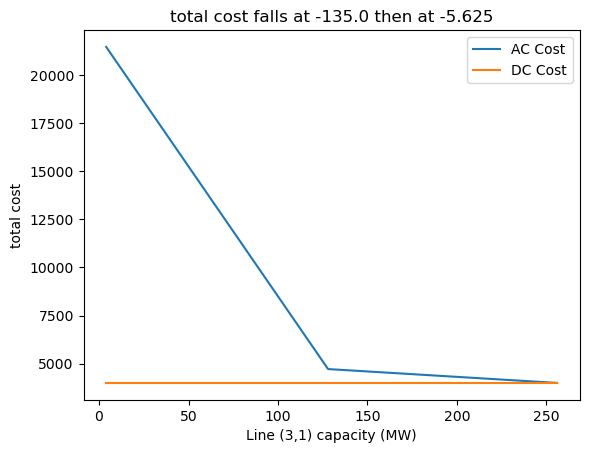

In [12]:
df = pd.DataFrame(dc_boss_map)

dfno1 = df[df['demand1']==0]

for i in [0]:
    # dfno1[dfno1['demand3']==i].plot(x = 'cap31', y = 'total_cost')
    cap = dfno1[dfno1['demand3']==i]['cap31'].values
    cost = dfno1[dfno1['demand3']==i]['total_cost'].values
    costDC = dfno1[dfno1['demand3']==i]['total_costDC'].values
    
    
    plt.plot(cap,cost, label = 'AC Cost')
    plt.plot(cap,costDC, label = 'DC Cost')
    
    top = np.max(dfno1[dfno1['demand3']==i]['total_cost'].values)
    xs= np.arange(4,256,5)
    # plt.plot( xs,  top -10*xs, label='all at low cost')
    plt.ylabel('total cost')
    plt.xlabel('Line (3,1) capacity (MW)')
    # plt.plot( xs,  top -100*xs, label='all at high cost')
    plt.legend()
    slope1 = (cost[2]-cost[0])/(cap[2]-cap[0])
    slope2 = (cost[-1]-cost[-2])/(cap[-1]-cap[-2])
    plt.title(f'total cost falls at {slope1} then at {slope2}')
    plt.show()

In [ ]:
# df = pd.DataFrame(dc_boss_map)

# dfno1 = df[df['demand1']==0]
# dfno3 = df[df['demand3']==0]

# heatmap_data = dfno3.pivot(index='demand1', columns='cap31', values='total_cost')
# %matplotlib inline
# # Plot heatmap
# plt.figure(figsize=(5, 5))
# sb.heatmap(heatmap_data/1000, cmap='viridis', annot=True, fmt=".1f")
# plt.title('total cost by load1 and cap31 ($1000s)')
# plt.show()

# heatmap_data = dfno1.pivot(index='demand3', columns='cap31', values='total_cost')
# %matplotlib inline
# # Plot heatmap
# plt.figure(figsize=(5, 5))
# sb.heatmap(heatmap_data/1000, cmap='viridis', annot=True, fmt=".1f")
# plt.title('total cost by load3 and cap31 ($1000s)')
# plt.show()

are we better off disconnecting the weak line?
yes

In [89]:
ac_lines = [(1, 2), (2,3)]
poss_ac_lines_cost = { (2, 3,2):1e3}
poss_dc_lines_cost, dc_lines = {(2,3,3):3e3}, []
poss_dc_lines = list(poss_dc_lines_cost.keys())
poss_ac_lines = list(poss_ac_lines_cost.keys())
generation_cost = {1: 100, 3:10}
cumu_flow = 600

sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {(1, 2):500, (2,3):500, (2,3,2):500}
dc_capacity = {key:500 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:500,2:0,3:500},
                susceptances = sus, line_capacity = line_capacity, 
                 obj = 'cost',
                 demands = {1: 0, 2: 400, 3: 0}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines_cost = poss_ac_lines_cost , save = False,
                 poss_dc_lines_cost  = poss_dc_lines_cost , generation_cost = generation_cost,
                 printout = False, max_new_ac = 1, max_new_dc = 1, max_new = 0, label="")
try: 
    tot_cost = np.sum([out['gen'][i]* generation_cost[i] for i in generation_cost])
except TypeError:
    tot_cost = -1
print(tot_cost)

4000.0


## 

In [110]:
ac_lines = [(1, 2), (3,1), (2,3)]
poss_ac_lines_cost = { (2, 3,2):1e3}
poss_dc_lines_cost, dc_lines = {(2,3,3):4e3}, []
poss_dc_lines = list(poss_dc_lines_cost.keys())
poss_ac_lines = list(poss_ac_lines_cost.keys())
cumu_flow = 4000

sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {(1, 2):5000, (3,1):100, (2,3):5000, (2,3,2):1000}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:5000, 2:0, 3:5000},
                susceptances = sus, line_capacity = line_capacity, 
                 obj = 'cost',
                 demands = {1: 0, 2: 4000, 3: 0}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines_cost = poss_ac_lines_cost , save = False,
                 poss_dc_lines_cost  = poss_dc_lines_cost , generation_cost = {1: 5, 3:1},
                 printout = True, max_new_ac = 1, max_new_dc = 1, max_new = 1, label="")

Status: Optimal
Objective Value: 11400.0

Generation at Each Bus:
Bus 1: 1850.0 MW
Bus 3: 2150.0 MW

AC Line Flows:
Line (1, 2): 1950.0 MW
Line (3, 1): 100.0 MW
Line (2, 3): -2050.0 MW
New AC Line (2, 3, 2): 0.0 MW
New DC Line (2, 3, 3): 0.0 MW

New AC Line Decisions:
Line (2, 3, 2): Not Added

New DC Line Decisions:
Line (2, 3, 3): Not Added

Voltage phases:
Bus 1: -0.07853981634196577 rads
Bus 2: -3.14159265359 rads
Bus 3: 0.07853981633742059 rads


### older stuff

In [76]:
ac_lines = []
poss_ac_lines_cost = {}
poss_dc_lines_cost, dc_lines = {}, [(1, 2), (3,1), (2,3)]
poss_dc_lines = list(poss_dc_lines_cost.keys())
poss_ac_lines = list(poss_ac_lines_cost.keys())

cumu_flow = 100
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {(1, 2):10, (3,1):32, (2,3):32}


out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:100,3:0},
                susceptances = sus, line_capacity = line_capacity, 
                 obj = 'cost',
                 demands = {1: 0, 2: 0, 3: 60}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines_cost = poss_ac_lines_cost, oldsave = False, save = False,
                 poss_dc_lines_cost = poss_dc_lines_cost, generation_cost = {1: 1000, 2: 100},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 22200.0

Generation at Each Bus:
Bus 1: 18.0 MW
Bus 2: 42.0 MW

AC Line Flows:

DC Line Flows:
Line (1, 2): -10.0 MW
Line (3, 1): -28.0 MW
Line (2, 3): 32.0 MW

Voltage phases:
Bus 1: None rads
Bus 2: None rads
Bus 3: None rads


In [26]:
ac_lines = []
poss_ac_lines_cost = {}
poss_dc_lines_cost, dc_lines = {(2,1):2e4}, [(1, 2), (3,1), (2,3)]
poss_dc_lines = list(poss_dc_lines_cost.keys())
poss_ac_lines = list(poss_ac_lines_cost.keys())

cumu_flow = 100
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {(1, 2):10, (3,1):32, (2,3):32}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:100,3:0},
                susceptances = sus, line_capacity = line_capacity, 
                 obj = 'cost',
                 demands = {1: 0, 2: 0, 3: 60}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines_cost = poss_ac_lines_cost, oldsave = False, save = False,
                 poss_dc_lines_cost = poss_dc_lines_cost, generation_cost = {1: 100, 2: 1},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 60.0

Generation at Each Bus:
Bus 2: 60.0 MW

AC Line Flows:

DC Line Flows:
Line (1, 2): -1000.0 MW
Line (3, 1): -1000.0 MW
Line (2, 3): -940.0 MW

Voltage phases:
Bus 1: None rads
Bus 2: None rads
Bus 3: None rads


In [16]:
ac_lines = [(1, 2), (4,1), (2,3), (3,4)]
poss_ac_lines_cost = {}
poss_dc_lines_cost, dc_lines = {(2,1):2e4}, []
poss_dc_lines = list(poss_dc_lines_cost.keys())
poss_ac_lines = list(poss_ac_lines_cost.keys())

cumu_flow = 1000
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:1000 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400},
                susceptances = sus, line_capacity = line_capacity, 
                 obj = 'cost',
                 demands = {1: 200, 2: 0, 3: 180, 4:20}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines_cost = poss_ac_lines_cost, oldsave = False, save = False,
                 poss_dc_lines_cost = poss_dc_lines_cost, generation_cost = {1: 120, 2: 25},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 48000.0

Generation at Each Bus:
Bus 1: 400.0 MW

AC Line Flows:
Line (1, 2): 95.0 MW
Line (4, 1): -105.0 MW
Line (2, 3): 95.0 MW
Line (3, 4): -85.0 MW

Voltage phases:
Bus 1: -1.9477874452266637 rads
Bus 2: -2.5446900494083318 rads
Bus 3: -3.14159265359 rads
Bus 4: -2.6075219024800864 rads


In [98]:
ac_lines = [(1, 2), (3,4), (2,3), (4,1), (3,1)]
poss_ac_lines = []
poss_dc_lines, dc_lines = [(2,4)], []
cumu_flow = 1000
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:1000 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:0,2:0,3:400, 4:0},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3,4], obj = 'cost',
                 demands = {1: 10, 2: 380, 3: 0, 4:10}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 120, 2: 25, 3:30},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 12000.0

Generation at Each Bus:
Bus 3: 400.0 MW

AC Line Flows:
Line (1, 2): 138.75 MW
Line (3, 4): 56.25 MW
Line (2, 3): -241.25 MW
Line (4, 1): 46.25 MW
Line (3, 1): 102.5 MW

Voltage phases:
Bus 1: -2.2698006922194054 rads
Bus 2: -3.1415926535899996 rads
Bus 3: -1.6257741982339213 rads
Bus 4: -1.9792033717625406 rads


In [130]:

t0 = time.time()
numbers = np.arange(12800)
pairs = list(itertools.combinations(numbers, 2))
print(time.time()-t0)
# 80, .00136
# 100, .0009
# 200, .003
# 400, .015
# 800, .054
# 1600, .4
# 3200, 1.7
# 6400, 6.77
# 12800, 43.8
# O(n^2)

43.824584007263184


In [172]:
def new_pairs(buses, pairs, n):
    # gets all possible pairs, picks some at random  not already in pairs
    # note that n buses can only have n*(n-1)/2 non repeating lines
    all_pairs = set(itertools.combinations(buses, 2))
    ready_pairs = set([(p[0],p[1]) for p in pairs] + [(p[1],p[0]) for p in pairs])
    remain = all_pairs - ready_pairs
    if len(remain) <= n:
        return list(remain)
    else:
        return random.sample(list(remain), n)

fully connected undefeated

In [201]:
ac_lines = new_pairs(np.arange(1,5), [], 12)
poss_ac_lines = [(4,3)]
poss_dc_lines, dc_lines = [(2,4,2)], []
cumu_flow = 1000
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:1000 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:0,2:0,3:400},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3,4], obj = 'cost',
                 demands = {1: 30, 2: 10, 3: 52, 4:300}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 120, 2: 25, 3:30},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 11760.0

Generation at Each Bus:
Bus 3: 392.0 MW

AC Line Flows:
Line (2, 3): -87.5 MW
Line (2, 4): 72.5 MW
Line (1, 2): -5.0 MW
Line (3, 4): 160.0 MW
Line (1, 3): -92.5 MW
Line (1, 4): 67.5 MW

Voltage phases:
Bus 1: -2.717477645355659 rads
Bus 2: -2.686061718819781 rads
Bus 3: -2.136283004441929 rads
Bus 4: -3.14159265359 rads


In [195]:
ac_lines = new_pairs(np.arange(1,7), [], 12)
poss_ac_lines = [(4,3)]
poss_dc_lines, dc_lines = [(2,4,2)], []
cumu_flow = 1000
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:1000 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:0,2:0,3:400, 4:0, 5:0, 6:0},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3,4,5 ,6], obj = 'cost',
                 demands = {1: 3, 2: 385, 3: 5, 4:1, 5:0, 6:1}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 120, 2: 25, 3:30},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 11850.0

Generation at Each Bus:
Bus 3: 395.0 MW

AC Line Flows:
Line (1, 6): -6.809523809523809 MW
Line (1, 3): -77.23809523809524 MW
Line (2, 4): -102.80952380952381 MW
Line (3, 5): 56.142857142857146 MW
Line (2, 3): -179.71428571428572 MW
Line (1, 2): 102.47619047619048 MW
Line (4, 5): -20.761904761904763 MW
Line (1, 4): -0.3333333333333333 MW
Line (1, 5): -21.095238095238095 MW
Line (5, 6): 14.285714285714286 MW
Line (3, 4): 76.9047619047619 MW
Line (4, 6): -6.476190476190476 MW

Voltage phases:
Bus 1: -2.4977157592546875 rads
Bus 2: -3.14159265359 rads
Bus 3: -2.0124144941004682 rads
Bus 4: -2.495621364152295 rads
Bus 5: -2.3651704692033184 rads
Bus 6: -2.4549302593058253 rads


# Cost benefits
some combinations of lines do yield cost benefits...

In [227]:
ac_lines = [(1, 2), (2, 3), (3,4), (4,5), (5,2), (3,6)]
poss_ac_lines = [ (2, 4), (3,5), (6,7)]
poss_dc_lines, dc_lines = [], []
cumu_flow = 1000
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:sus[key]*3 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:0,3:0,4:0,5:400, 6:0, 7:0},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3, 4, 5, 6, 7], obj = 'cost',
                 demands = {1: 50, 2: 25, 3: 50, 4: 25, 5:50, 6:25, 7:75}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 100, 2: 1, 5: 1},
                 printout = True, max_new_ac = 1, max_new_dc = 1, max_new = 1, label="")

Status: Optimal
Objective Value: 300.0

Generation at Each Bus:
Bus 5: 300.0 MW

AC Line Flows:
Line (1, 2): -50.0 MW
Line (2, 3): 62.5 MW
Line (3, 4): -87.5 MW
Line (4, 5): -112.5 MW
Line (5, 2): 137.5 MW
Line (3, 6): 100.0 MW
New AC Line (2, 4): 0.0 MW
New AC Line (3, 5): 0.0 MW
New AC Line (6, 7): 75.0 MW

New AC Line Decisions:
Line (2, 4): Not Added
Line (3, 5): Not Added
Line (6, 7): Added

New DC Line Decisions:

Voltage phases:
Bus 1: -1.9634954084975784 rads
Bus 2: -1.6493361431388045 rads
Bus 3: -2.04203522483727 rads
Bus 4: -1.4922565104594174 rads
Bus 5: -0.7853981634021786 rads
Bus 6: -2.6703537555548156 rads
Bus 7: -3.14159265359 rads


In [358]:
ac_lines = new_pairs(np.arange(1,8), [], 24)
poss_ac_lines = [ (2, 4,2), (3,5,2), (6,7,2)]
poss_dc_lines, dc_lines = [], []
cumu_flow = 1200
sus = {key:cumu_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:sus[key]*3 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:0,3:0,4:0,5:400, 6:0, 7:0},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3, 4, 5, 6, 7], obj = 'cost',
                 demands = {1: 50, 2: 25, 3: 50, 4: 25, 5:100, 6:25, 7:75}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 1000, 2: 1, 5: 1},
                 printout = False, max_new_ac = 1, max_new_dc = 1, max_new = 0, label="")
prob.objective.value()

349.99999999999994

In [360]:
ac_lines
''' these lead to a high cost
[(1, 2),
 (3, 5),
 (2, 3),
 (4, 7),
 (5, 6),
 (1, 5),
 (2, 4),
 (2, 7),
 (1, 7),
 (4, 6),
 (2, 6),
 (1, 4)]
'''

' these lead to a high cost\n[(1, 2),\n (3, 5),\n (2, 3),\n (4, 7),\n (5, 6),\n (1, 5),\n (2, 4),\n (2, 7),\n (1, 7),\n (4, 6),\n (2, 6),\n (1, 4)]\n'

# Multiple Generators

For a node with two transmission connections to generators to fail via susceptance, we need:

max flow delivered from both lines to undercut the demand

In [66]:
ac_lines = [(1, 2), (2, 3), (3,4), (4,5), ]
poss_ac_lines = [ (2, 4), (3,5),]
poss_dc_lines, dc_lines = [], []
cum_flow = 50*4+60*3+40*2+30
# straining the network if gen 5 was alone
sus = {key:cum_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:sus[key]*3 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:0,3:0,4:0,5:400},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3, 4, 5], obj = 'cost',
                 demands = {1: 50, 2: 60, 3: 40, 4: 30, 5:50}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 120, 2: 25, 5: 10},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 2300.0

Generation at Each Bus:
Bus 5: 230.0 MW

AC Line Flows:
Line (1, 2): -50.0 MW
Line (2, 3): -110.0 MW
Line (3, 4): -150.0 MW
Line (4, 5): -180.0 MW

Voltage phases:
Bus 1: -3.14159265359 rads
Bus 2: -2.500451295714282 rads
Bus 3: -1.0899403083877195 rads
Bus 4: 0.8334837652394063 rads
Bus 5: 3.14159265359 rads


In [54]:
1/np.pi*180
#we'd like less than half radian angle differences...

57.29577951308232

In [68]:
ac_lines = [(1, 2), (2, 3), (3,4), (4,5), ]
poss_ac_lines = [ (2, 4), (3,5),]
poss_dc_lines, dc_lines = [], []
cum_flow = 60*3+40*2+30
# straining the network so gen 5 supplies all but bus 1 which handles own load
sus = {key:cum_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:sus[key]*3 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:0,3:0,4:0,5:400},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3, 4, 5], obj = 'cost',
                 demands = {1: 50, 2: 60, 3: 40, 4: 30, 5:50}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 120, 2: 25, 5: 10},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Status: Optimal
Objective Value: 7800.0

Generation at Each Bus:
Bus 1: 50.0 MW
Bus 5: 180.0 MW

AC Line Flows:
Line (1, 2): 0.0 MW
Line (2, 3): -60.0 MW
Line (3, 4): -100.0 MW
Line (4, 5): -130.0 MW

Voltage phases:
Bus 1: -3.141592653587885 rads
Bus 2: -3.14159265359 rads
Bus 3: -1.8416232796914918 rads
Bus 4: 0.32499234347409844 rads
Bus 5: 3.14159265359 rads


In [9]:
ac_lines = [(1, 2), (2, 3), (3,4), (4,5), ]
poss_ac_lines = [ (2, 4), (3,5),]
poss_dc_lines, dc_lines = [], []
cum_flow = 110
# gen 5 would need to send 40*2 + 30 to supply 3, 
# gen 1 would need to send 40*2 + 60 to supply 3,
# gen 5 is less strained. 
# if we substitute that 40 for a 20, each contirbuting half

sus = {key:cum_flow/(2*np.pi) for key in ac_lines+poss_ac_lines}
line_capacity = {key:sus[key]*3 for key in ac_lines+poss_ac_lines+dc_lines + poss_dc_lines}
dc_capacity = {key:1000 for key in dc_lines + poss_dc_lines}
line_capacity.update(dc_capacity)

out, prob = flow.ACDC_TEP_OPF(gen_capacity = {1:400,2:0,3:0,4:0,5:400},
                susceptances = sus, line_capacity = line_capacity, 
                 line_expansion_cost = 1000, buses = [1, 2, 3, 4, 5], obj = 'cost',
                 demands = {1: 50, 2: 60, 3: 40, 4: 30, 5:50}, cut = False,
                 ac_lines = ac_lines, dc_lines = dc_lines,
                 poss_ac_lines = poss_ac_lines, oldsave = False, save = False,
                 poss_dc_lines = poss_dc_lines, generation_cost = {1: 120, 2: 25, 5: 10},
                 printout = True, max_new_ac = 0, max_new_dc = 0, label="")

Did not converge
See returned problem object


NameError: name 'sns' is not defined